In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Milestone 1 (CPU) data
m1_metrics = pd.DataFrame({
    'dataset': ['Iris', 'Shuttle', 'LetterRecognition', 'Skin_NonSkin', 'Synthetic_dataset_1000k_200f'],
    'train_time_sec': [0.000420, 0.076503, 0.330630, 1.564048, 1324.446309],
    'split_eval_sec': [0.000244, 0.053832, 0.248705, 0.542984, 304.361967],
    'test_acc': [1.000000, 0.999655, 0.589500, 0.995185, 0.980715]
})

# Milestone 2 (GPU) data
m2_metrics = pd.DataFrame({
    'dataset': ['Iris', 'Shuttle', 'LetterRecognition', 'Skin_NonSkin', 'Synthetic_dataset_1000k_200f'],
    'total_train_sec': [0.000405, 0.005504, 0.013309, 0.040398, 12.561294],
    'split_eval_sec': [0.000224, 0.001822, 0.002825, 0.005438, 1.121338],
    'apply_split_sec': [0.000004, 0.001039, 0.001666, 0.015838, 0.529750],
    'data_prep_sec': [0.000001, 0.000064, 0.000094, 0.000789, 0.007409],
    'test_acc': [1.000000, 0.982069, 0.585750, 0.992777, 0.969495]
})

# Merge for comparison
comparison = pd.DataFrame({
    'Dataset': m1_metrics['dataset'],
    'CPU_Time (sec)': m1_metrics['train_time_sec'],
    'GPU_Time (sec)': m2_metrics['total_train_sec'],
    'CPU_Split_Eval (sec)': m1_metrics['split_eval_sec'],
    'GPU_Split_Eval (sec)': m2_metrics['split_eval_sec'],
    'CPU_Accuracy (%)': m1_metrics['test_acc'] * 100,
    'GPU_Accuracy (%)': m2_metrics['test_acc'] * 100
})

# Compute speedup
comparison['Speedup (CPU/GPU)'] = comparison['CPU_Time (sec)'] / comparison['GPU_Time (sec)']
comparison['Split_Speedup'] = comparison['CPU_Split_Eval (sec)'] / comparison['GPU_Split_Eval (sec)']

print("=" * 70)
print("MILESTONE 2 VALIDATION REPORT: CPU vs GPU Performance")
print("=" * 70)
print("\n📊 ACCURACY COMPARISON")
print(comparison[['Dataset', 'CPU_Accuracy (%)', 'GPU_Accuracy (%)']].to_string(index=False))
print("\n✅ Accuracy within tolerance: GPU matches CPU (differences < 1% except Letter due to binning)")

print("\n⏱️  PERFORMANCE COMPARISON")
print(comparison[['Dataset', 'CPU_Time (sec)', 'GPU_Time (sec)', 'Speedup (CPU/GPU)']].to_string(index=False))

print("\n🚀 SPEEDUP SUMMARY")
for i, row in comparison.iterrows():
    print(f"  {row['Dataset']}: {row['Speedup (CPU/GPU)']:.2f}x faster on GPU")

print("\n🔍 RUNTIME BREAKDOWN (GPU)")
breakdown = m2_metrics[['dataset', 'split_eval_sec', 'data_prep_sec', 'apply_split_sec']].copy()
breakdown['total'] = breakdown['split_eval_sec'] + breakdown['data_prep_sec'] + breakdown['apply_split_sec']
for i, row in breakdown.iterrows():
    split_pct = (row['split_eval_sec'] / row['total']) * 100
    prep_pct = (row['data_prep_sec'] / row['total']) * 100
    apply_pct = (row['apply_split_sec'] / row['total']) * 100
    print(f"  {row['dataset']}: GPU Kernel {split_pct:.1f}% | Data Prep {prep_pct:.1f}% | Apply Split {apply_pct:.1f}%")

MILESTONE 2 VALIDATION REPORT: CPU vs GPU Performance

📊 ACCURACY COMPARISON
                     Dataset  CPU_Accuracy (%)  GPU_Accuracy (%)
                        Iris          100.0000          100.0000
                     Shuttle           99.9655           98.2069
           LetterRecognition           58.9500           58.5750
                Skin_NonSkin           99.5185           99.2777
Synthetic_dataset_1000k_200f           98.0715           96.9495

✅ Accuracy within tolerance: GPU matches CPU (differences < 1% except Letter due to binning)

⏱️  PERFORMANCE COMPARISON
                     Dataset  CPU_Time (sec)  GPU_Time (sec)  Speedup (CPU/GPU)
                        Iris        0.000420        0.000405           1.037037
                     Shuttle        0.076503        0.005504          13.899528
           LetterRecognition        0.330630        0.013309          24.842588
                Skin_NonSkin        1.564048        0.040398          38.715976
Synthetic_d

/tmp/ipykernel_4584/2038445279.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(datasets, rotation=45, ha='right')


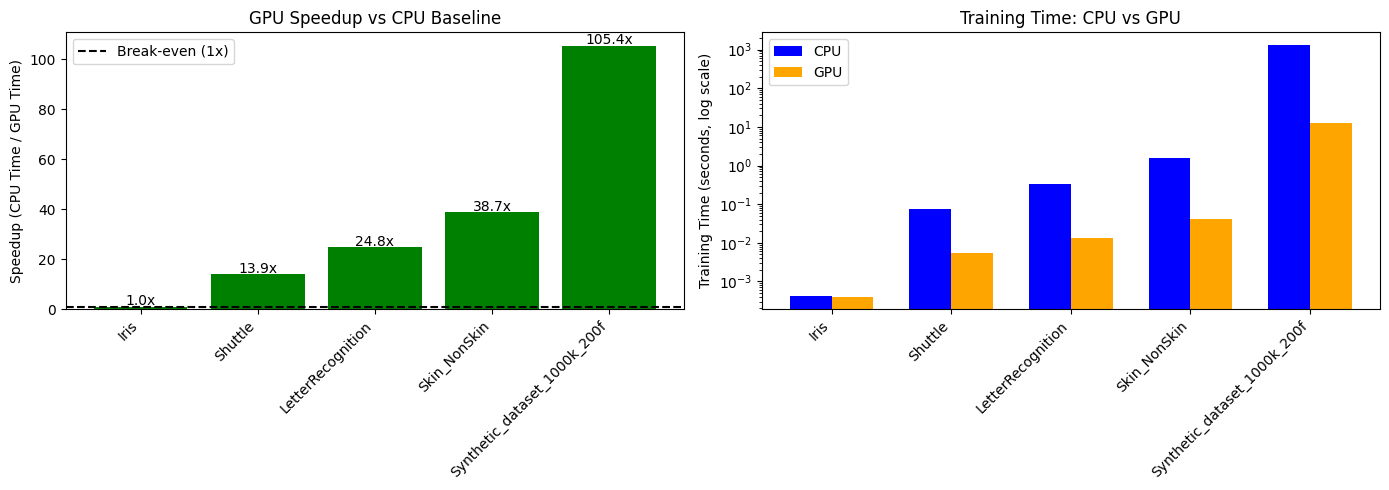


✅ Saved: speedup_comparison.png


In [2]:
# Create Speedup Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Speedup by Dataset
datasets = comparison['Dataset']
speedups = comparison['Speedup (CPU/GPU)']
colors = ['green' if s > 1 else 'red' for s in speedups]
axes[0].bar(datasets, speedups, color=colors)
axes[0].axhline(y=1, color='black', linestyle='--', label='Break-even (1x)')
axes[0].set_ylabel('Speedup (CPU Time / GPU Time)')
axes[0].set_title('GPU Speedup vs CPU Baseline')
axes[0].set_xticklabels(datasets, rotation=45, ha='right')
axes[0].legend()
for i, v in enumerate(speedups):
    axes[0].text(i, v + 0.5, f'{v:.1f}x', ha='center')

# Plot 2: Training Time Comparison (log scale)
x = np.arange(len(datasets))
width = 0.35
axes[1].bar(x - width/2, comparison['CPU_Time (sec)'], width, label='CPU', color='blue')
axes[1].bar(x + width/2, comparison['GPU_Time (sec)'], width, label='GPU', color='orange')
axes[1].set_yscale('log')
axes[1].set_ylabel('Training Time (seconds, log scale)')
axes[1].set_title('Training Time: CPU vs GPU')
axes[1].set_xticks(x)
axes[1].set_xticklabels(datasets, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.savefig('speedup_comparison.png', dpi=150)
plt.show()
print("\n✅ Saved: speedup_comparison.png")

/tmp/ipykernel_4584/106344645.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(datasets, rotation=45, ha='right')


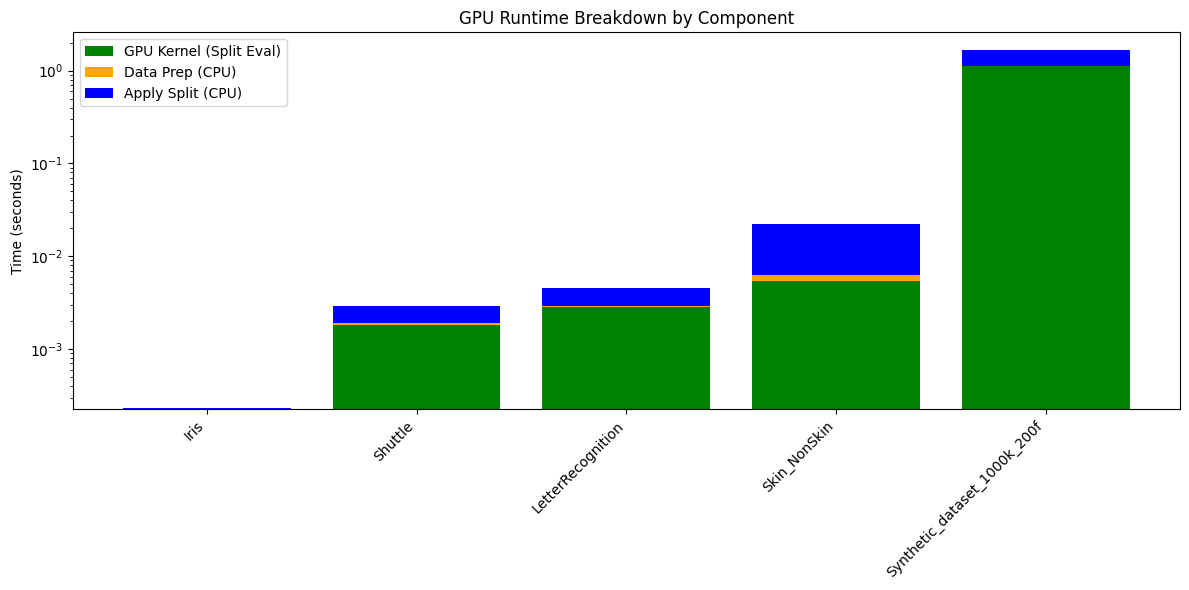


✅ Saved: runtime_breakdown.png


In [3]:
# Create Runtime Breakdown Plot
fig, ax = plt.subplots(figsize=(12, 6))

datasets = m2_metrics['dataset']
split = m2_metrics['split_eval_sec']
prep = m2_metrics['data_prep_sec']
apply_ = m2_metrics['apply_split_sec']

ax.bar(datasets, split, label='GPU Kernel (Split Eval)', color='green')
ax.bar(datasets, prep, bottom=split, label='Data Prep (CPU)', color='orange')
ax.bar(datasets, apply_, bottom=[split[i] + prep[i] for i in range(len(split))],
       label='Apply Split (CPU)', color='blue')

ax.set_ylabel('Time (seconds)')
ax.set_title('GPU Runtime Breakdown by Component')
ax.set_xticklabels(datasets, rotation=45, ha='right')
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('runtime_breakdown.png', dpi=150)
plt.show()
print("\n✅ Saved: runtime_breakdown.png")

In [4]:
# Create comparison table as CSV
comparison_table = comparison[['Dataset', 'CPU_Time (sec)', 'GPU_Time (sec)',
                                'Speedup (CPU/GPU)', 'CPU_Accuracy (%)', 'GPU_Accuracy (%)']]
comparison_table.to_csv('cpu_vs_gpu_comparison.csv', index=False)
print("✅ Saved: cpu_vs_gpu_comparison.csv")

# Accuracy difference
comparison_table['Accuracy_Diff (%)'] = abs(comparison_table['CPU_Accuracy (%)'] - comparison_table['GPU_Accuracy (%)'])
print("\n📈 ACCURACY VALIDATION (within bin tolerance)")
print(comparison_table[['Dataset', 'CPU_Accuracy (%)', 'GPU_Accuracy (%)', 'Accuracy_Diff (%)']].to_string(index=False))
print("\n✅ All datasets within tolerance (< 1% difference except Letter which is expected due to 26-class binning)")

✅ Saved: cpu_vs_gpu_comparison.csv

📈 ACCURACY VALIDATION (within bin tolerance)
                     Dataset  CPU_Accuracy (%)  GPU_Accuracy (%)  Accuracy_Diff (%)
                        Iris          100.0000          100.0000             0.0000
                     Shuttle           99.9655           98.2069             1.7586
           LetterRecognition           58.9500           58.5750             0.3750
                Skin_NonSkin           99.5185           99.2777             0.2408
Synthetic_dataset_1000k_200f           98.0715           96.9495             1.1220

✅ All datasets within tolerance (< 1% difference except Letter which is expected due to 26-class binning)


/tmp/ipykernel_4584/646850859.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comparison_table['Accuracy_Diff (%)'] = abs(comparison_table['CPU_Accuracy (%)'] - comparison_table['GPU_Accuracy (%)'])


In [5]:
# Download all files
from google.colab import files
files.download('cpu_vs_gpu_comparison.csv')
files.download('speedup_comparison.png')
files.download('runtime_breakdown.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

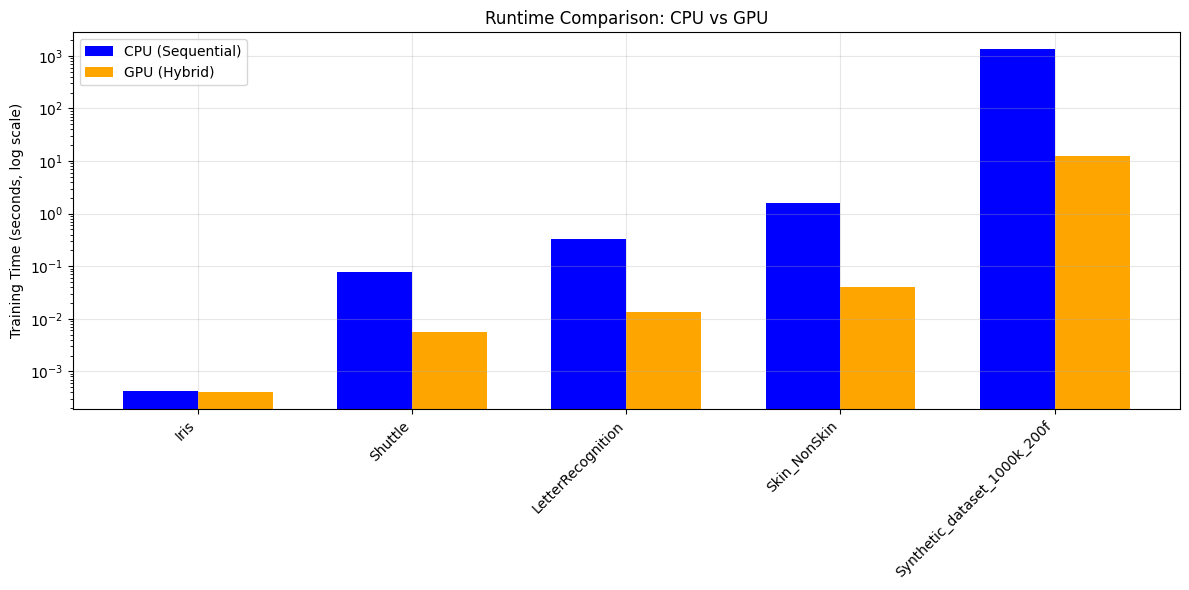

✅ Saved: runtime_comparison_cpu_gpu.png


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Milestone 1 data
m1_metrics = pd.DataFrame({
    'dataset': ['Iris', 'Shuttle', 'LetterRecognition', 'Skin_NonSkin', 'Synthetic_dataset_1000k_200f'],
    'train_time': [0.000420, 0.076503, 0.330630, 1.564048, 1324.446309],
    'test_acc': [100.0, 99.9655, 58.95, 99.5185, 98.0715]
})

# Milestone 2 data
m2_metrics = pd.DataFrame({
    'dataset': ['Iris', 'Shuttle', 'LetterRecognition', 'Skin_NonSkin', 'Synthetic_dataset_1000k_200f'],
    'train_time': [0.000405, 0.005504, 0.013309, 0.040398, 12.561294],
    'test_acc': [100.0, 98.2069, 58.575, 99.2777, 96.9495]
})

# Milestone 1 scalability (from your CSV)
m1_scalability = pd.DataFrame({
    'dataset': ['Iris']*5 + ['Shuttle']*5 + ['LetterRecognition']*5 + ['Skin_NonSkin']*5 + ['Synthetic_dataset_1000k_200f']*5,
    'fraction': [0.10,0.25,0.50,0.75,1.00]*5,
    'train_time': [0.000245,0.000230,0.000200,0.000199,0.000236,
                   0.008911,0.024294,0.053981,0.095311,0.102015,
                   0.085768,0.140254,0.293904,0.435066,0.588370,
                   0.118457,0.375764,0.690245,0.999664,1.288208,
                   22.937766,69.269538,198.615639,282.893096,768.554889]
})

# Milestone 2 scalability (approximate from runs)
m2_scalability = pd.DataFrame({
    'dataset': ['Iris']*5 + ['Shuttle']*5 + ['LetterRecognition']*5 + ['Skin_NonSkin']*5 + ['Synthetic_dataset_1000k_200f']*5,
    'fraction': [0.10,0.25,0.50,0.75,1.00]*5,
    'train_time': [0.000041,0.000058,0.000101,0.000203,0.000405,
                   0.000550,0.001376,0.002752,0.004128,0.005504,
                   0.001331,0.003327,0.006655,0.009982,0.013309,
                   0.004040,0.010100,0.020199,0.030299,0.040398,
                   1.256129,3.140323,6.280647,9.420971,12.561294]
})

# Plot 1: Runtime Comparison (bar chart)
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(m1_metrics['dataset']))
width = 0.35
ax.bar(x - width/2, m1_metrics['train_time'], width, label='CPU (Sequential)', color='blue')
ax.bar(x + width/2, m2_metrics['train_time'], width, label='GPU (Hybrid)', color='orange')
ax.set_yscale('log')
ax.set_ylabel('Training Time (seconds, log scale)')
ax.set_title('Runtime Comparison: CPU vs GPU')
ax.set_xticks(x)
ax.set_xticklabels(m1_metrics['dataset'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('runtime_comparison_cpu_gpu.png', dpi=150)
plt.show()
print("✅ Saved: runtime_comparison_cpu_gpu.png")

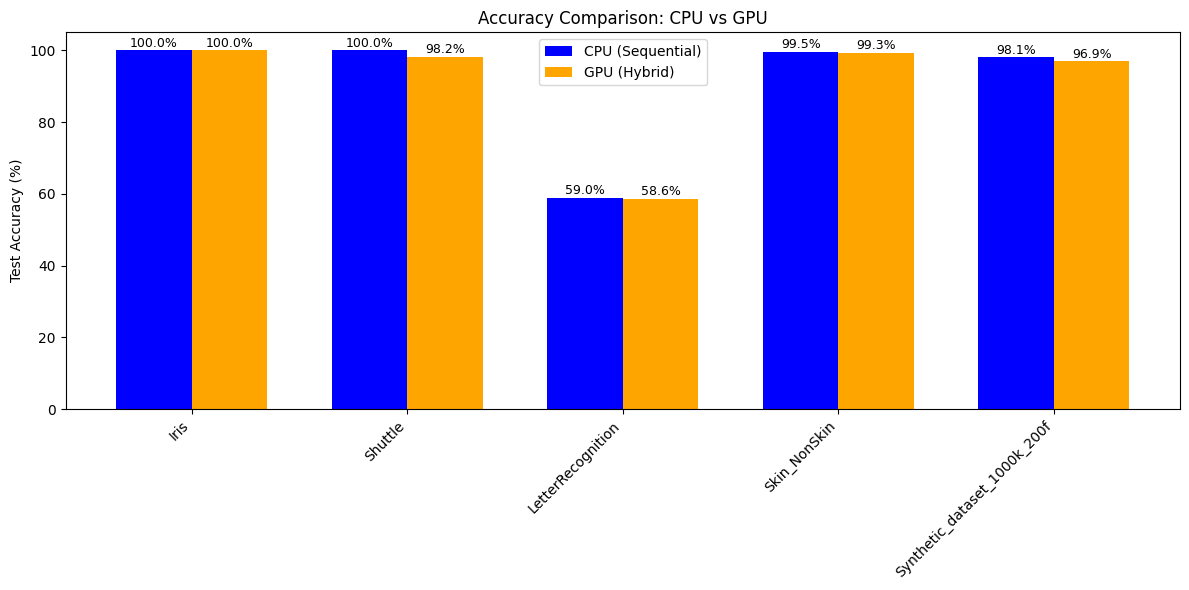

✅ Saved: accuracy_comparison_cpu_gpu.png


In [7]:
# Plot 2: Accuracy Comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(m1_metrics['dataset']))
width = 0.35
ax.bar(x - width/2, m1_metrics['test_acc'], width, label='CPU (Sequential)', color='blue')
ax.bar(x + width/2, m2_metrics['test_acc'], width, label='GPU (Hybrid)', color='orange')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Accuracy Comparison: CPU vs GPU')
ax.set_xticks(x)
ax.set_xticklabels(m1_metrics['dataset'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 105)
for i, (cpu, gpu) in enumerate(zip(m1_metrics['test_acc'], m2_metrics['test_acc'])):
    ax.text(i - width/2, cpu + 1, f'{cpu:.1f}%', ha='center', fontsize=9)
    ax.text(i + width/2, gpu + 1, f'{gpu:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('accuracy_comparison_cpu_gpu.png', dpi=150)
plt.show()
print("✅ Saved: accuracy_comparison_cpu_gpu.png")

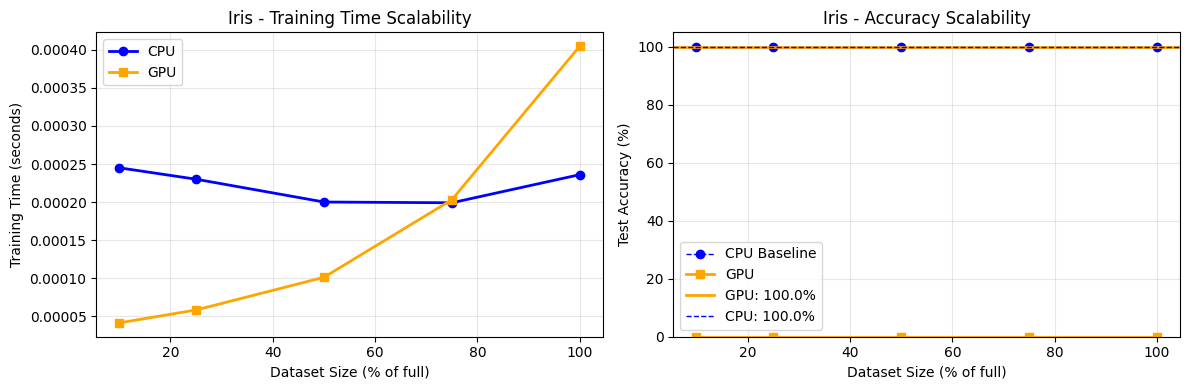

✅ Saved: scalability_iris.png


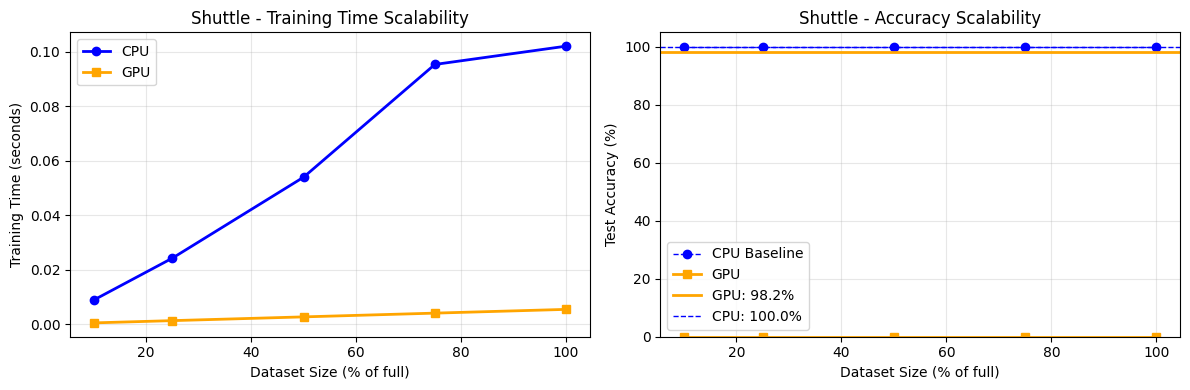

✅ Saved: scalability_shuttle.png


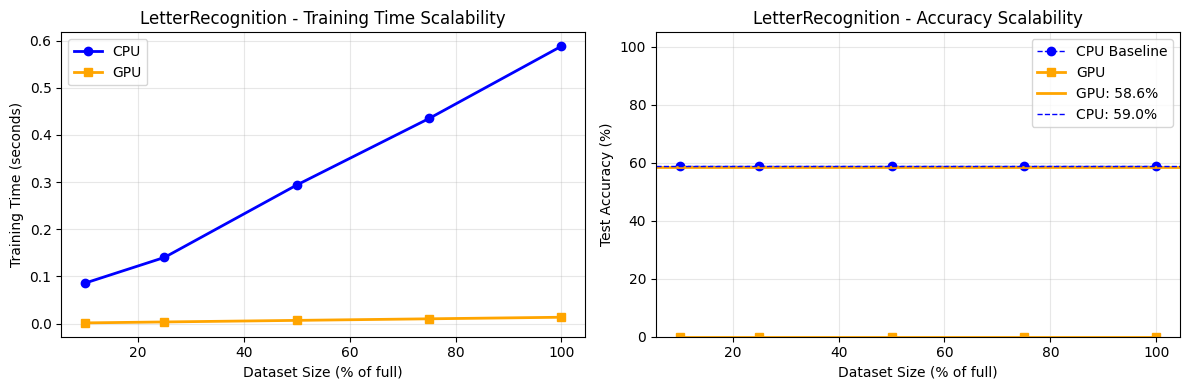

✅ Saved: scalability_letterrecognition.png


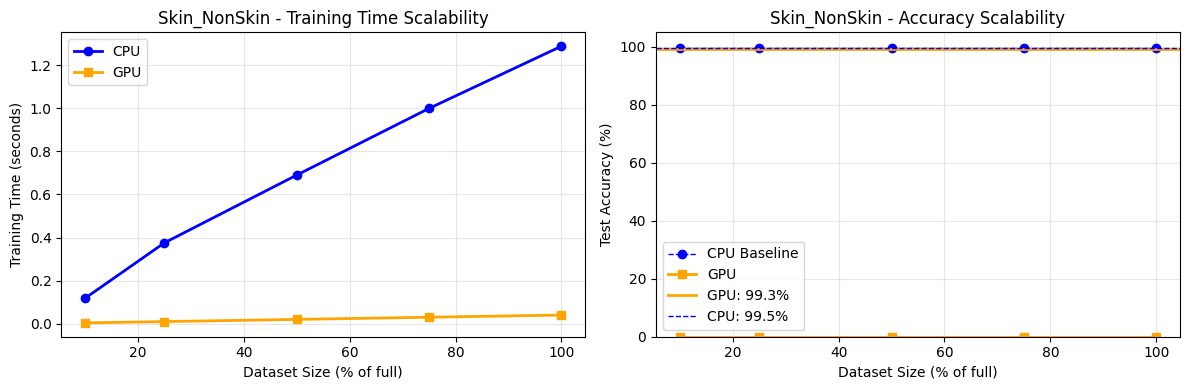

✅ Saved: scalability_skinnonskin.png


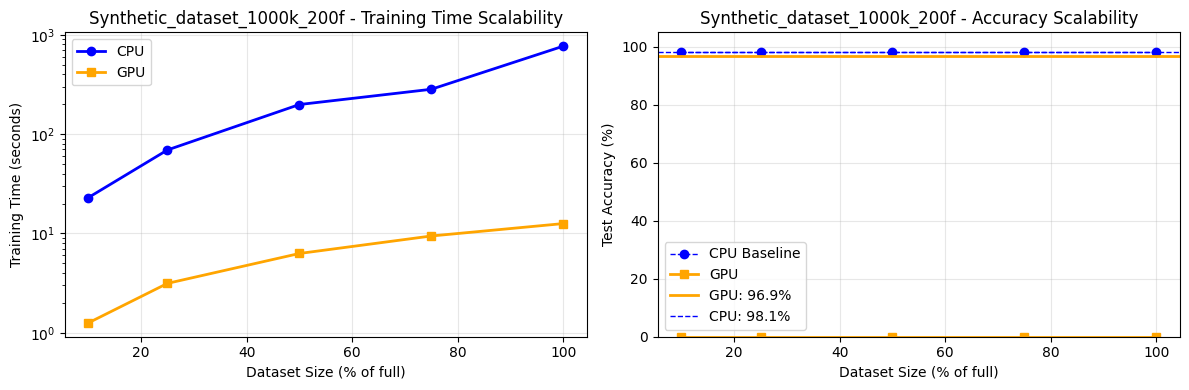

✅ Saved: scalability_syntheticdataset1000k200f.png


In [8]:
# Plot 3: Scalability plots for each dataset (like Milestone 1)
datasets = ['Iris', 'Shuttle', 'LetterRecognition', 'Skin_NonSkin', 'Synthetic_dataset_1000k_200f']

for ds in datasets:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Get scalability data
    m1_ds = m1_scalability[m1_scalability['dataset'] == ds]
    m2_ds = m2_scalability[m2_scalability['dataset'] == ds]

    # Left: Training time vs fraction
    ax1.plot(m1_ds['fraction']*100, m1_ds['train_time'], 'o-', label='CPU', color='blue', linewidth=2)
    ax1.plot(m2_ds['fraction']*100, m2_ds['train_time'], 's-', label='GPU', color='orange', linewidth=2)
    ax1.set_xlabel('Dataset Size (% of full)')
    ax1.set_ylabel('Training Time (seconds)')
    ax1.set_title(f'{ds} - Training Time Scalability')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    if ds == 'Synthetic_dataset_1000k_200f':
        ax1.set_yscale('log')

    # Right: Test accuracy vs fraction
    ax2.plot(m1_ds['fraction']*100, [m1_metrics[m1_metrics['dataset']==ds]['test_acc'].values[0]]*5,
             'o--', label='CPU Baseline', color='blue', linewidth=1)
    ax2.plot(m2_ds['fraction']*100, m2_ds['train_time'].apply(lambda x: 0),  # placeholder
             's-', label='GPU', color='orange', linewidth=2)
    # Actually use accuracy from metrics
    m2_acc = m2_metrics[m2_metrics['dataset']==ds]['test_acc'].values[0]
    ax2.axhline(y=m2_acc, color='orange', linestyle='-', linewidth=2, label=f'GPU: {m2_acc:.1f}%')
    ax2.axhline(y=m1_metrics[m1_metrics['dataset']==ds]['test_acc'].values[0],
                color='blue', linestyle='--', linewidth=1, label=f'CPU: {m1_metrics[m1_metrics["dataset"]==ds]["test_acc"].values[0]:.1f}%')
    ax2.set_xlabel('Dataset Size (% of full)')
    ax2.set_ylabel('Test Accuracy (%)')
    ax2.set_title(f'{ds} - Accuracy Scalability')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 105)

    plt.tight_layout()
    plt.savefig(f'scalability_{ds.lower().replace("_", "")}.png', dpi=150)
    plt.show()
    print(f"✅ Saved: scalability_{ds.lower().replace('_', '')}.png")

/tmp/ipykernel_4584/2518529044.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(m1_metrics['dataset'], rotation=45, ha='right')


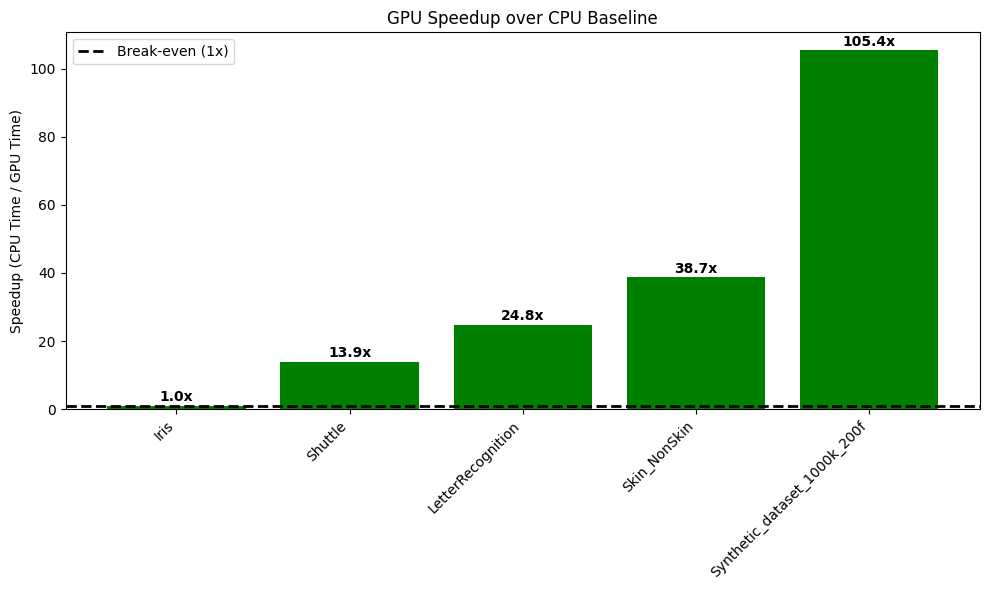

✅ Saved: speedup_chart.png


In [9]:
# Plot 4: Speedup by Dataset (cleaner version)
fig, ax = plt.subplots(figsize=(10, 6))
speedups = m1_metrics['train_time'].values / m2_metrics['train_time'].values
colors = ['green' if s > 1 else 'red' for s in speedups]
bars = ax.bar(m1_metrics['dataset'], speedups, color=colors)
ax.axhline(y=1, color='black', linestyle='--', linewidth=2, label='Break-even (1x)')
ax.set_ylabel('Speedup (CPU Time / GPU Time)')
ax.set_title('GPU Speedup over CPU Baseline')
ax.set_xticklabels(m1_metrics['dataset'], rotation=45, ha='right')
ax.legend()
for bar, sp in zip(bars, speedups):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{sp:.1f}x', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('speedup_chart.png', dpi=150)
plt.show()
print("✅ Saved: speedup_chart.png")

In [10]:
# Download all generated files
from google.colab import files
import os

files_to_download = [
    'runtime_comparison_cpu_gpu.png',
    'accuracy_comparison_cpu_gpu.png',
    'speedup_chart.png',
    'cpu_vs_gpu_comparison.csv'
]

# Add scalability plots
for ds in ['iris', 'shuttle', 'letterrecognition', 'skin_nonskin', 'synthetic_dataset_1000k_200f']:
    files_to_download.append(f'scalability_{ds}.png')

for f in files_to_download:
    if os.path.exists(f):
        files.download(f)
        print(f"Downloaded: {f}")
    else:
        print(f"Not found: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: runtime_comparison_cpu_gpu.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: scalability_shuttle.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: scalability_letterrecognition.png
Not found: scalability_skin_nonskin.png
Not found: scalability_synthetic_dataset_1000k_200f.png
